In [1]:
using LinearAlgebra
using Distributions
using Plots
using LaTeXStrings
using Printf
using FileIO
import JLD2
using CairoMakie 
using MeasureBase


In [2]:
using Newtrinos

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: wrong dep version loaded (2), include_dependency fhash change (2))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0xc06c8c49939d6791, 0xe8d7da4db887846c, 0xa270f943f04843de, 0x750f5120d5835f0b, 0xa62aa65bb92b0bce, 0xd7ea77ddbaf0af06, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


In [3]:
osc_cfg_NNM = Newtrinos.osc.OscillationConfig(
    flavour = Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction = Newtrinos.osc.SI(),
    )

osc = Newtrinos.osc.configure(osc_cfg_NNM)
atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()
xsec = Newtrinos.xsec.configure()

physics_NNM = (; osc, atm_flux, earth_layers, xsec);

In [4]:
experiments_NNM = (;
    juno = Newtrinos.juno.configure(physics_NNM)
);

[ Info: Loading juno data


In [5]:
p_NNM = Newtrinos.get_params(experiments_NNM)

(N = 20.0, juno_accidental_norm = 1.0, juno_atmnc_norm = 1.0, juno_co_norm = 1.0, juno_detection_epsilon = 1.0, juno_fast_neutron_norm = 1.0, juno_geo_rate_norm = 1.0, juno_geo_shape_eps = 0.0, juno_lihe_norm = 1.0, juno_res_a = 0.0261, juno_res_b = 0.0082, juno_res_c = 0.0123, juno_world_reactor_norm = 1.0, junotao_energy_scale = 1.0, junotao_flux_scale = 1.0, junotao_shape_eps = 0.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.05, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [6]:
params_NNM_new = (junotao_flux_scale = 1.0, junotao_energy_scale = 1.0, juno_detection_epsilon = 1.0, juno_res_a = 0.0261, junotao_shape_eps = 0.0, juno_geo_shape_eps = 0.0, juno_geo_rate_norm = 1.0, juno_accidental_norm = 1.0, juno_world_reactor_norm = 1.0, juno_lihe_norm = 1.0, juno_co_norm = 1.0, juno_atmnc_norm = 1.0, juno_fast_neutron_norm = 1.0, detection_epsilon = 1.0, m₀ = 0.01, η = 1.05, N = 20, r = 1e-8, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

(junotao_flux_scale = 1.0, junotao_energy_scale = 1.0, juno_detection_epsilon = 1.0, juno_res_a = 0.0261, junotao_shape_eps = 0.0, juno_geo_shape_eps = 0.0, juno_geo_rate_norm = 1.0, juno_accidental_norm = 1.0, juno_world_reactor_norm = 1.0, juno_lihe_norm = 1.0, juno_co_norm = 1.0, juno_atmnc_norm = 1.0, juno_fast_neutron_norm = 1.0, detection_epsilon = 1.0, m₀ = 0.01, η = 1.05, N = 20, r = 1.0e-8, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [7]:
pri_NNM = Newtrinos.get_priors(experiments_NNM)

(N = DiscreteUniform(a=2, b=40), juno_accidental_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.01); lower=0.0, upper=Inf), juno_atmnc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.5); lower=0.0, upper=Inf), juno_co_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.5); lower=0.0, upper=Inf), juno_detection_epsilon = Truncated(Normal{Float64}(μ=1.0, σ=0.01); lower=0.0, upper=Inf), juno_fast_neutron_norm = Truncated(Normal{Float64}(μ=1.0, σ=1.0); lower=0.0, upper=Inf), juno_geo_rate_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.3); lower=0.0, upper=Inf), juno_geo_shape_eps = Normal{Float64}(μ=0.0, σ=1.0), juno_lihe_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.0, upper=Inf), juno_res_a = Truncated(Normal{Float64}(μ=0.0261, σ=0.0002); lower=0.0, upper=Inf), juno_res_b = Truncated(Normal{Float64}(μ=0.0082, σ=0.0001); lower=0.0, upper=Inf), juno_res_c = Truncated(Normal{Float64}(μ=0.0123, σ=0.0004); lower=0.0, upper=Inf), juno_world_reactor_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.02); lowe

In [8]:
priors_NNM_new = (junotao_flux_scale = Truncated(Normal(1.0, 0.02), 0.0, Inf), junotao_energy_scale = Truncated(Normal(1.0, 0.005), 0.0, Inf), juno_detection_epsilon = Truncated(Normal(1.0, 0.01), 0.0, Inf), juno_res_a = Truncated(Normal(0.0261, 0.0002), 0.0, Inf), junotao_shape_eps = Normal(0,1), juno_geo_shape_eps = Normal(0,1), juno_geo_rate_norm = Truncated(Normal(1.0, 0.30), 0.0, Inf), juno_accidental_norm = Truncated(Normal(1.0, 0.01), 0.0, Inf), juno_world_reactor_norm = Truncated(Normal(1.0, 0.02), 0.0, Inf), juno_lihe_norm = Truncated(Normal(1.0, 0.20), 0.0, Inf), juno_co_norm = Truncated(Normal(1.0, 0.50), 0.0, Inf), juno_atmnc_norm = Truncated(Normal(1.0, 0.50), 0.0, Inf), juno_fast_neutron_norm = Truncated(Normal(1.0, 1.0), 0.0, Inf), detection_epsilon = Normal(1.0, 0.01), m₀ = LogUniform(1e-6, 0.05), η = Uniform(1.000000001, 1.1), N = DiscreteUniform(2, 40), r = Uniform(1e-8, 1), Δm²₂₁ = Uniform(6.5e-5, 9.0e-5), Δm²₃₁ = Uniform(0.002, 0.003), δCP = Uniform(0.0, 6.283185307179586), θ₁₂ = Uniform(0.4205343352839651, 0.7853981633974483), θ₁₃ = Uniform(0.1, 0.2), θ₂₃ = Uniform(0.5235987755982988, 1.0471975511965976))

(junotao_flux_scale = Truncated(Normal{Float64}(μ=1.0, σ=0.02); lower=0.0, upper=Inf), junotao_energy_scale = Truncated(Normal{Float64}(μ=1.0, σ=0.005); lower=0.0, upper=Inf), juno_detection_epsilon = Truncated(Normal{Float64}(μ=1.0, σ=0.01); lower=0.0, upper=Inf), juno_res_a = Truncated(Normal{Float64}(μ=0.0261, σ=0.0002); lower=0.0, upper=Inf), junotao_shape_eps = Normal{Float64}(μ=0.0, σ=1.0), juno_geo_shape_eps = Normal{Float64}(μ=0.0, σ=1.0), juno_geo_rate_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.3); lower=0.0, upper=Inf), juno_accidental_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.01); lower=0.0, upper=Inf), juno_world_reactor_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.02); lower=0.0, upper=Inf), juno_lihe_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.0, upper=Inf), juno_co_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.5); lower=0.0, upper=Inf), juno_atmnc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.5); lower=0.0, upper=Inf), juno_fast_neutron_norm = Truncated(Normal{

In [9]:
a_NNM = Newtrinos.juno.get_assets(physics_NNM, 6.0);

[ Info: Loading juno data


In [10]:
E_vis_NNM = a_NNM.E_bins_visible
E_nu_NNM = a_NNM.visible_to_neutrino_interp.(E_vis_NNM .* p_NNM.junotao_energy_scale)
L_km_NNM = a_NNM.reactors.Baseline_m ./ 1e3
P_NNM = physics_NNM.osc.osc_prob(E_nu_NNM ./ 1e3, L_km_NNM, p_NNM; anti=true)
P_ee_NNM = P_NNM[:, :, 1, 1]
prob_weighted_NNM = vec(sum(P_ee_NNM .* a_NNM.reactors.Flux_Factor', dims=2))
pro_NNM = (P_ee = P_ee_NNM, prob_weighted_flat = prob_weighted_NNM)

(P_ee = [0.8899422752158674 0.8675480071565532 … 0.8216556002367116 0.3813513244195913; 0.8229871859363884 0.8336831582299647 … 0.8714342188163723 0.31459862825713214; … ; 0.7404734199156301 0.7458831558857727 … 0.7405802190465639 0.5212706043781717; 0.7466272375147602 0.7454634896667224 … 0.7434236461415644 0.5128525030325799], prob_weighted_flat = [0.8433913756098128, 0.8238173810364792, 0.8409940698320966, 0.7840100137632524, 0.7667695985226095, 0.7855881523902588, 0.7463157363251202, 0.7040626836858086, 0.7203684972121844, 0.7216136551314513  …  0.730825088077249, 0.732855553535961, 0.7342316919360833, 0.7369946839812125, 0.7352708580056014, 0.7350518579221351, 0.7376998628715453, 0.7360844545489124, 0.7356255805510352, 0.7359611878478677])

In [11]:
using CSV
using DataFrames
df_j= CSV.read(joinpath("/home/sofialon/Newtrinos.jl/src/experiments/juno/juno_NO_observed.csv"),DataFrame)
observed_juno = df_j.Counts
lik_NNM = Newtrinos.generate_likelihood(experiments_NNM, observed_juno);

In [12]:
osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg_SM)
atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc)

experiments_SM = (;
    juno = Newtrinos.juno.configure(physics_SM)
)

p_SM = Newtrinos.get_params(experiments_SM)
pri_SM = Newtrinos.get_priors(experiments_SM)
a_SM = Newtrinos.juno.get_assets(physics_SM, 6.0)
E_vis_SM = a_SM.E_bins_visible
E_nu_SM = a_SM.visible_to_neutrino_interp.(E_vis_SM .* p_SM.junotao_energy_scale)
L_km_SM = a_SM.reactors.Baseline_m ./ 1e3
P_SM = physics_SM.osc.osc_prob(E_nu_SM ./ 1e3, L_km_SM, p_SM; anti=true)
P_ee_SM = P_SM[:, :, 1, 1]
prob_weighted_SM = vec(sum(P_ee_SM .* a_SM.reactors.Flux_Factor', dims=2))
pro_SM = (P_ee = P_ee_SM, prob_weighted_flat = prob_weighted_SM)
lik_SM = Newtrinos.generate_likelihood(experiments_SM, observed_juno);

[ Info: Loading juno data
[ Info: Loading juno data


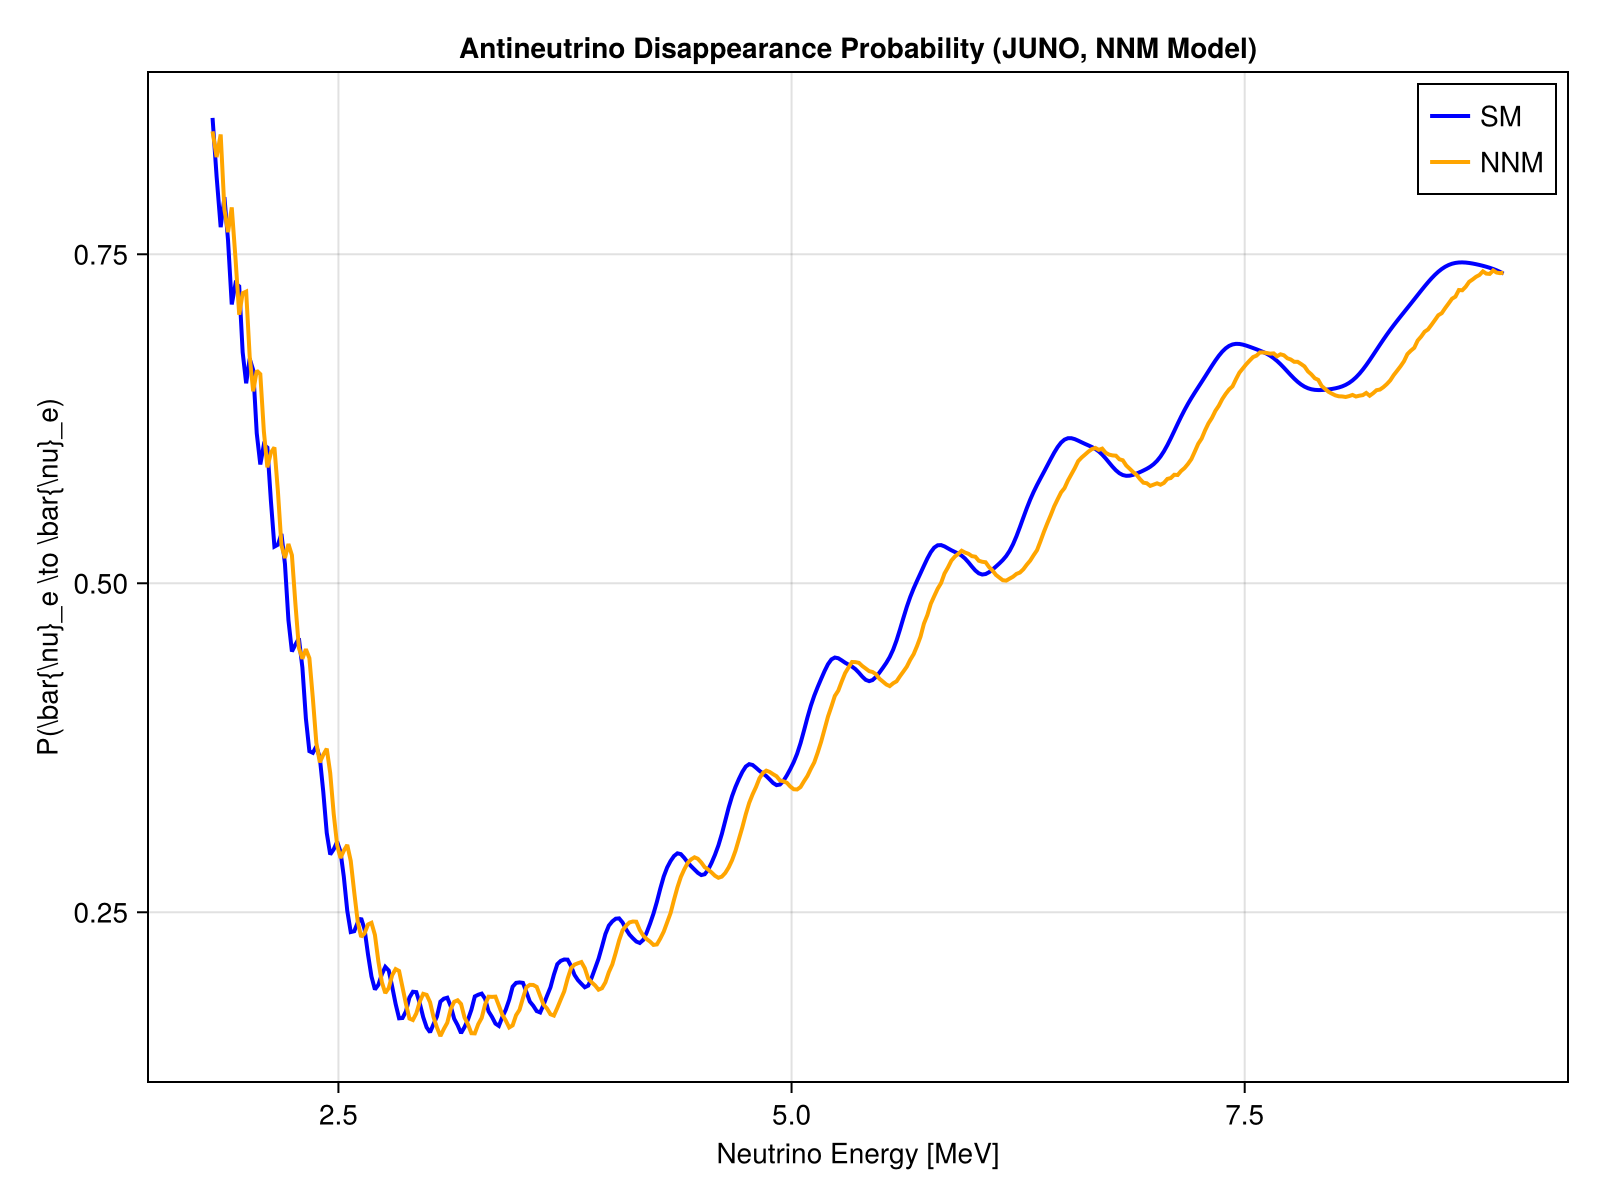

In [13]:
P_ee_NNM = pro_NNM.P_ee    

E_vis_NNM = a_NNM.E_bins_visible  

E_nu_NNM = a_NNM.visible_to_neutrino_interp.(E_vis_NNM .* p_NNM.junotao_energy_scale) 

P_ee_SM = pro_SM.P_ee   

E_vis_SM = a_SM.E_bins_visible  

E_nu_SM = a_SM.visible_to_neutrino_interp.(E_vis_SM .* p_SM.junotao_energy_scale)  

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1],
    xlabel="Neutrino Energy [MeV]",
    ylabel="P(\\bar{\\nu}_e \\to \\bar{\\nu}_e)",
    title="Antineutrino Disappearance Probability (JUNO, NNM Model)"
)

CairoMakie.lines!(ax, E_nu_SM, pro_SM.prob_weighted_flat, color=:blue, linewidth=2, label="SM")
CairoMakie.lines!(ax, E_nu_NNM, pro_NNM.prob_weighted_flat, color=:orange, linewidth=2, label="NNM")

axislegend(ax)
fig

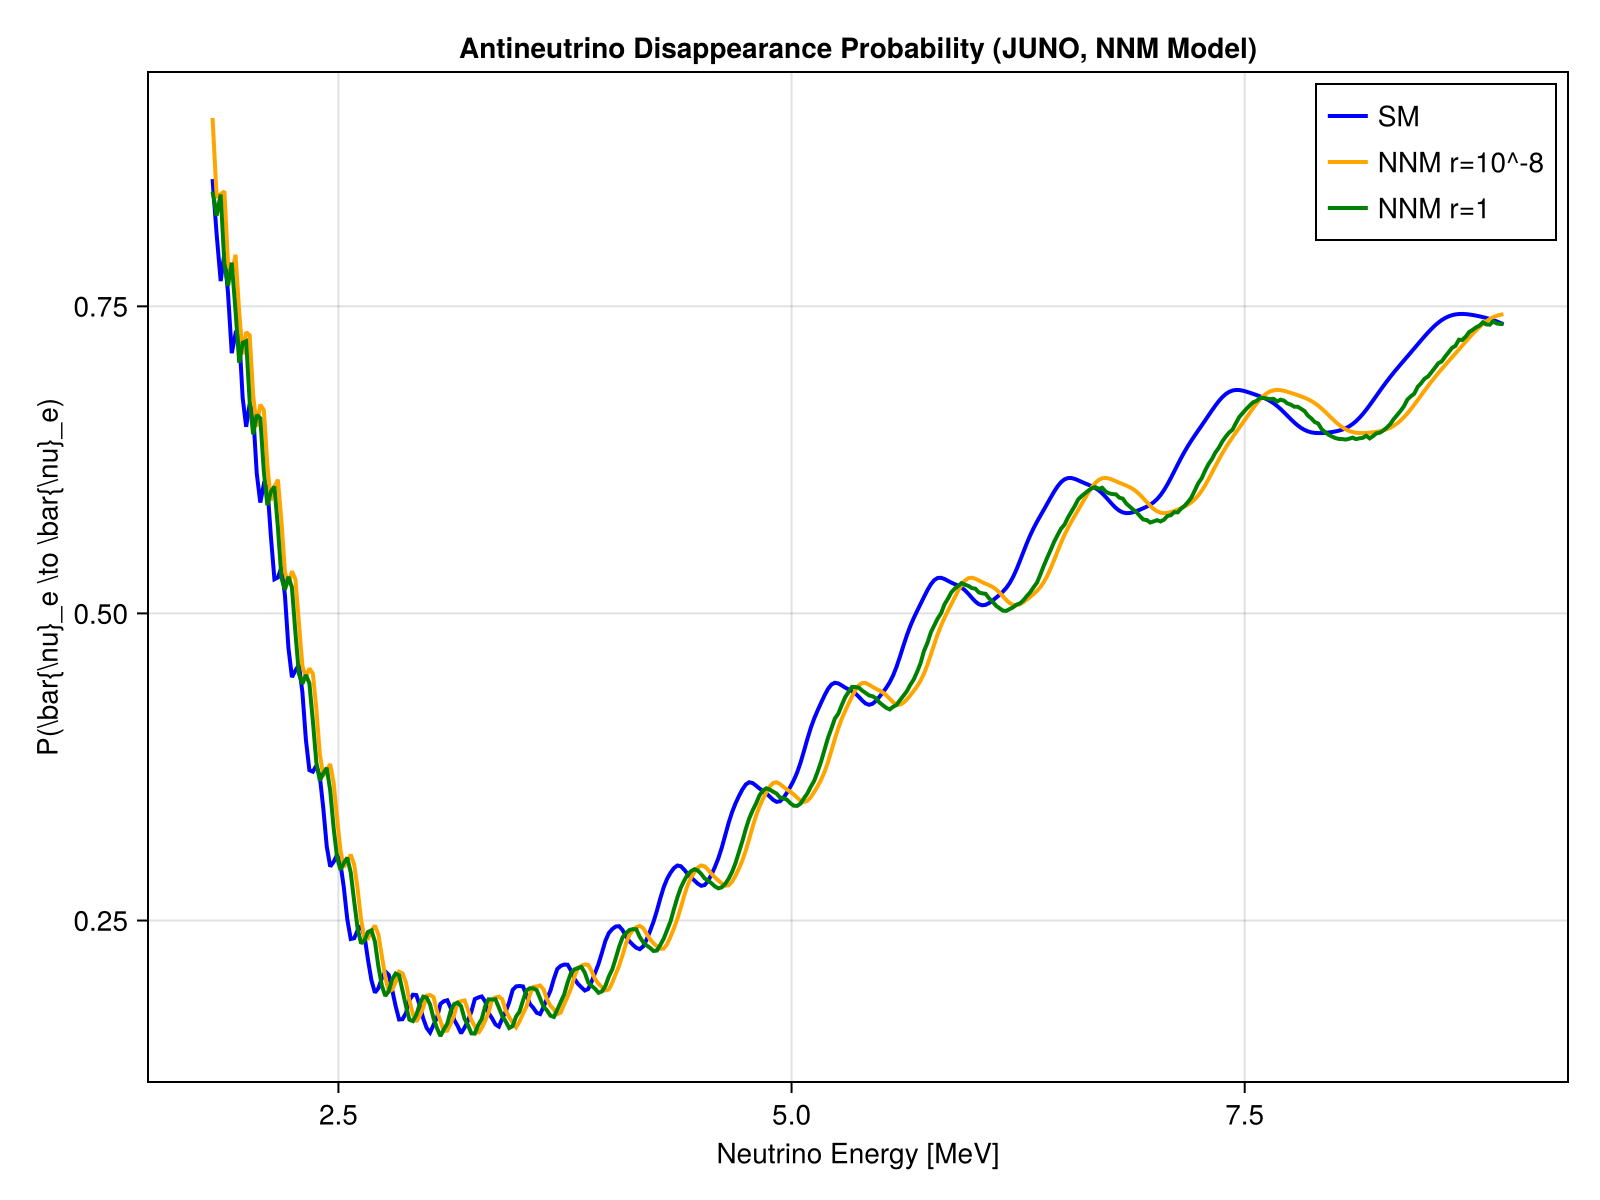

In [14]:
E_vis_NNM = a_NNM.E_bins_visible
E_nu_NNM = a_NNM.visible_to_neutrino_interp.(E_vis_NNM .* params_NNM_new.junotao_energy_scale)
L_km_NNM = a_NNM.reactors.Baseline_m ./ 1e3
P_NNM_lar = physics_NNM.osc.osc_prob(E_nu_NNM ./ 1e3, L_km_NNM, params_NNM_new; anti=true)
P_ee_NNM = P_NNM_lar[:, :, 1, 1]
prob_weighted_NNM_lar = vec(sum(P_ee_NNM .* a_NNM.reactors.Flux_Factor', dims=2))
pro_NNM_lar = (P_ee = P_ee_NNM, prob_weighted_flat = prob_weighted_NNM_lar)

E_vis_SM = a_SM.E_bins_visible
E_nu_SM = a_SM.visible_to_neutrino_interp.(E_vis_SM .* p_SM.junotao_energy_scale)

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1],
    xlabel="Neutrino Energy [MeV]",
    ylabel="P(\\bar{\\nu}_e \\to \\bar{\\nu}_e)",
    title="Antineutrino Disappearance Probability (JUNO, NNM Model)"
 )

CairoMakie.lines!(ax, E_nu_SM, pro_SM.prob_weighted_flat, color=:blue, linewidth=2, label="SM")
CairoMakie.lines!(ax, E_nu_NNM, pro_NNM_lar.prob_weighted_flat, color=:orange, linewidth=2, label="NNM r=10^-8")
CairoMakie.lines!(ax, E_nu_NNM, pro_NNM.prob_weighted_flat, color=:green, linewidth=2, label="NNM r=1")

axislegend(ax)
fig

In [44]:
scan_NNM = Newtrinos.scan(lik_NNM, pri_NNM, (N=30,  m₀=30), p_NNM)
pl_sc_NNM = CairoMakie.plot(scan_NNM)

Number of threads: 4
Total points to compute: 900


LoadError: MethodError: no method matching logpdf(::ValueShapes.NamedTupleDist{(:juno,), Tuple{Product{Discrete, Poisson{Float64}, Vector{Poisson{Float64}}}}, Tuple{ValueShapes.ValueAccessor{ValueShapes.ArrayShape{Real, 1}}}, NamedTuple}, ::Vector{Int64})
The function `logpdf` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  logpdf([91m::EmpiricalDistributions.MvBinnedDist{T, N, U, ET, VT, MT, VU, AU} where {U<:Real, ET<:NTuple{N, AbstractVector{<:Real}}, VT<:AbstractVector{T}, MT<:AbstractMatrix{T}, VU<:AbstractVector{U}, AU<:AbstractArray{U, N}}[39m, ::AbstractVector{<:Real}) where {T, N}
[0m[90m   @[39m [36mEmpiricalDistributions[39m [90m~/.julia/packages/EmpiricalDistributions/g4juW/src/[39m[90m[4mmv_binned_dist.jl:146[24m[39m
[0m  logpdf(::ValueShapes.NamedTupleDist{names}, [91m::NamedTuple{names}[39m) where names
[0m[90m   @[39m [32mValueShapes[39m [90m~/.julia/packages/ValueShapes/MRmei/src/[39m[9

In [ ]:
logL_NNM = logdensityof(lik_NNM, p_NNM)
println("Llh for NNM model: ", logL_NNM)

logL_SM = logdensityof(lik_SM, p_SM)  
println("Llh for SM model: ", logL_SM)

In [ ]:
llh_profile_1D_N = [maximum(scan_NNM.values.log_posterior[i, :]) for i in 1:size(scan_NNM.values.log_posterior, 1)]

q_values_1D = -2 * (llh_profile_1D_N .- maximum(llh_profile_1D_N))
println("Full q_values_1D: ", q_values_1D)

N_scan_points_1D = scan_NNM.axes.N

Plots.plot(N_scan_points_1D, q_values_1D, marker=:o, xlabel="N", ylabel="-2ΔLLH", title="")
Plots.hline!([2.71], label="90% CL (1 dof)", linestyle=:dash)
Plots.hline!([3.84], label="95% CL (1 dof)", linestyle=:dot)

In [ ]:
Plots.heatmap(scan_NNM.axes.N, scan_NNM.axes.m₀, scan_NNM.values.log_posterior, xlabel="N", ylabel="m₀", title="2D Log-Posterior", xscale=:log10)

In [ ]:
Plots.plot(scan_NNM.axes.m₀, scan_NNM.values.log_posterior[:, findmin(abs.(scan_NNM.axes.N .- 20))[2]], xlabel="m₀", ylabel="Log-Posterior", title="Slice at N = 20")

In [ ]:
idx_peak = findmin(abs.(scan_NNM.axes.N .- 15))[2]
idx_dip = findmin(abs.(scan_NNM.axes.N .- 25))[2]
p1 = Plots.plot(scan_NNM.axes.m₀, scan_NNM.values.log_posterior[idx_peak, :], xlabel="m₀ (eV)", ylabel="Log-Posterior", title="Slice at N = 15", label="Log-Posterior")
p2 = Plots.plot(scan_NNM.axes.m₀, scan_NNM.values.log_posterior[idx_dip, :], xlabel="m₀ (eV)", ylabel="Log-Posterior", title="Slice at N = 25", label="Log-Posterior")
Plots.plot(p1, p2, layout=(2,1))

In [ ]:
scan_NNM_larprio = Newtrinos.scan(lik_NNM, priors_NNM_new, (N=30,  m₀=30), p_NNM)
pl_NNM_larprio = CairoMakie.plot(scan_NNM_larprio)

In [ ]:
llh_profile_1D_N = [maximum(scan_NNM_larprio.values.log_posterior[i, :]) for i in 1:size(scan_NNM_larprio.values.log_posterior, 1)]

q_values_1D = -2 * (llh_profile_1D_N .- maximum(llh_profile_1D_N))
println("Full q_values_1D: ", q_values_1D)

N_scan_points_1D = scan_NNM_larprio.axes.N

Plots.plot(N_scan_points_1D, q_values_1D, marker=:o, xlabel="N", ylabel="-2ΔLLH", title="")
Plots.hline!([2.71], label="90% CL (1 dof)", linestyle=:dash)
Plots.hline!([3.84], label="95% CL (1 dof)", linestyle=:dot)